1. Cadrage et besoin client

La SAE 2.04 porte sur l’exploitation d’une base de données de capteurs dans un environnement industriel. L’entreprise étudiée est une usine produisant des rouleaux de papier à l’aide d’une machine industrielle équipée de nombreux capteurs répartis sur la chaîne de fabrication.

Ces capteurs permettent de suivre différents paramètres importants pour la qualité de production, comme la température, l’humidité ou d’autres mesures techniques. Cependant, ils peuvent se dérégler avec le temps ou tomber en panne, ce qui peut entraîner des mesures incorrectes et nuire au contrôle de la qualité.

Le besoin du client est donc de vérifier si les capteurs fonctionnent correctement. Pour cela, il faut comparer les mesures automatiques enregistrées par les capteurs avec les mesures manuelles réalisées par les techniciens, détecter les écarts anormaux, produire des visualisations compréhensibles et proposer une amélioration de la base de données pour mieux suivre la fiabilité des capteurs.

Objectifs

Les objectifs fonctionnels de la SAE sont les suivants :

    -générer une carte de contrôle pour un capteur choisi ;

    -analyser les écarts entre mesures automatiques et manuelles ;

    -produire un histogramme et des indicateurs statistiques comme la moyenne et l’écart-type ;

    -implémenter des règles de détection d’anomalies avec p-valeurs ;

    -détecter une dérive éventuelle par régression linéaire ;

    -proposer une extension de la base de données pour suivre la fiabilité des capteurs.

2.Choix du capteur et périmètre du projet
Dans cette SAE, un capteur ou un jeu de données sera choisi dans la base de données fournie afin d’effectuer une analyse statistique complète. Le capteur retenu doit permettre de comparer une mesure automatique avec une mesure manuelle, de calculer l’écart entre les deux et d’étudier la fiabilité des mesures.

Le projet se limite à l’exploitation des données, à leur traitement dans SQL et Python, à la création de cartes de contrôle, d’histogrammes et de tests de détection, ainsi qu’à la conception d’une extension de la base de données pour suivre la fiabilité des capteurs. Les actions de maintenance, d’installation ou de développement d’interface ne font pas partie du périmètre.


In [65]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from math import comb

conn = psycopg.connect(
    host="localhost",
    dbname="postgres",
    user="postgres",
    password="admin"
)

SENSOR_ID = 1

In [66]:
def Erreurs(conn, sensor_id):
    query_points = """
        WITH errors AS (
            SELECT
                cm.controltimestamp,
                cm.controlvalue - sm.sensorvalue AS error
            FROM controlmeasurement cm
            JOIN sensormeasurement sm
                ON sm.sensorid = cm.sensorid
               AND sm.timestamp = cm.sensortimestamp
            WHERE cm.sensorid = %s
        )
        SELECT controltimestamp, error
        FROM errors
        WHERE controltimestamp BETWEEN '2023-01-02' AND '2023-01-09'
        ORDER BY controltimestamp;
    """

    with conn.cursor() as cur:
        cur.execute(query_points, (sensor_id,))
        rows = cur.fetchall()

    timestamps = [r[0] for r in rows]
    errors = [r[1] for r in rows]
    return timestamps, errors

timestamps, errors = Erreurs(conn, SENSOR_ID)
print("Nombre de points :", len(errors))

Nombre de points : 28


In [67]:
def Stats(conn, sensor_id):
    query_stats = """
        WITH errors AS (
            SELECT
                cm.controltimestamp,
                cm.controlvalue - sm.sensorvalue AS error
            FROM controlmeasurement cm
            JOIN sensormeasurement sm
                ON sm.sensorid = cm.sensorid
               AND sm.timestamp = cm.sensortimestamp
            WHERE cm.sensorid = %s
        )
        SELECT
            AVG(error)    AS mu,
            STDDEV(error) AS sigma
        FROM errors;
    """

    with conn.cursor() as cur:
        cur.execute(query_stats, (sensor_id,))
        return cur.fetchone()


mu, sigma = Stats(conn, SENSOR_ID)
print("mu   =", mu)
print("sigma=", sigma)

mu   = -0.003744319871616289
sigma= 0.4127852186522945


In [68]:
def ToutesLesErreurs(conn, sensor_id):
    query_all_errors = """
        WITH errors AS (
            SELECT
                cm.controltimestamp,
                cm.controlvalue - sm.sensorvalue AS error
            FROM controlmeasurement cm
            JOIN sensormeasurement sm
                ON sm.sensorid = cm.sensorid
               AND sm.timestamp = cm.sensortimestamp
            WHERE cm.sensorid = %s
        )
        SELECT error
        FROM errors;
    """

    with conn.cursor() as cur:
        cur.execute(query_all_errors, (sensor_id,))
        rows = cur.fetchall()

    return np.array([r[0] for r in rows], dtype=float)


errors_all = ToutesLesErreurs(conn, SENSOR_ID)
print("Total number of errors:", len(errors_all))

Total number of errors: 2005


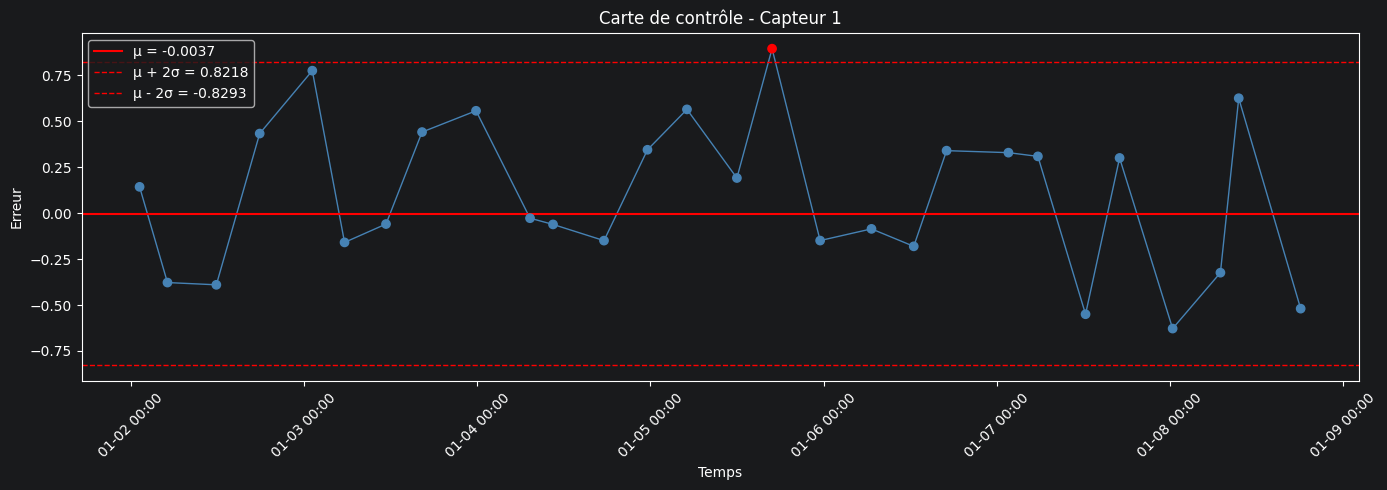

In [69]:
def TraceCarte(timestamps, errors, mu, sigma, sensor_id):
    fig, ax = plt.subplots(figsize=(14, 5))

    colors = ["red" if (e < mu - 2*sigma or e > mu + 2*sigma) else "steelblue" for e in errors]
    ax.plot(timestamps, errors, color="steelblue", linewidth=1)
    ax.scatter(timestamps, errors, color=colors, zorder=5)

    ax.axhline(mu, color="red", linestyle="-", linewidth=1.5, label=f"µ = {mu:.4f}")
    ax.axhline(mu + 2*sigma, color="red", linestyle="--", linewidth=1, label=f"µ + 2σ = {mu+2*sigma:.4f}")
    ax.axhline(mu - 2*sigma, color="red", linestyle="--", linewidth=1, label=f"µ - 2σ = {mu-2*sigma:.4f}")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    plt.xticks(rotation=45)

    ax.set_title(f"Carte de contrôle - Capteur {sensor_id}")
    ax.set_xlabel("Temps")
    ax.set_ylabel("Erreur")
    ax.legend()
    plt.tight_layout()
    plt.show()


TraceCarte(timestamps, errors, mu, sigma, SENSOR_ID)

In [70]:
def GetAllErrors(conn, sensor_id):
    sql = """
        WITH errors AS (
            SELECT
                cm.controltimestamp,
                cm.controlvalue - sm.sensorvalue AS error
            FROM controlmeasurement cm
            JOIN sensormeasurement sm
                ON sm.sensorid = cm.sensorid
               AND sm.timestamp = cm.sensortimestamp
            WHERE cm.sensorid = %s
        )
        SELECT error
        FROM errors;
    """
    with conn.cursor() as cur:
        cur.execute(sql, (sensor_id,))
        rows = cur.fetchall()
    return np.array([r[0] for r in rows], dtype=float)


errors_all = GetAllErrors(conn, SENSOR_ID)
print("Total number of errors:", len(errors_all))

Total number of errors: 2005


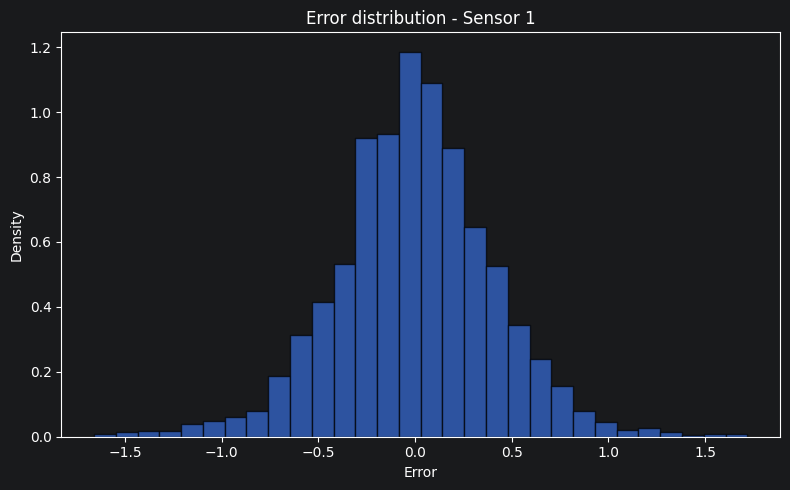

In [71]:
def PlotHistogram(errors_all, sensor_id):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(errors_all, bins=30, density=True, edgecolor="black", alpha=0.7)
    ax.set_title(f"Error distribution - Sensor {sensor_id}")
    ax.set_xlabel("Error")
    ax.set_ylabel("Density")
    plt.tight_layout()
    plt.show()


PlotHistogram(errors_all, SENSOR_ID)

In [72]:
def ProportionsInsideIntervals(errors_all, mu, sigma):
    N = len(errors_all)
    intervals = [("±1σ", 1), ("±2σ", 2), ("±3σ", 3)]
    results = []
    for label, k in intervals:
        lower = mu - k * sigma
        upper = mu + k * sigma
        count = np.sum((errors_all >= lower) & (errors_all <= upper))
        percent = 100 * count / N
        results.append((label, count, percent))
    return results


results = ProportionsInsideIntervals(errors_all, mu, sigma)
for label, count, percent in results:
    print(f"{label}: {count} points, {percent:.2f}% of all errors")

±1σ: 1428 points, 71.22% of all errors
±2σ: 1903 points, 94.91% of all errors
±3σ: 1984 points, 98.95% of all errors


In [73]:
def ProportionsOutsideIntervals(errors_all, mu, sigma):
    N = len(errors_all)
    intervals = [("±1σ", 1), ("±2σ", 2), ("±3σ", 3)]
    results = []
    for label, k in intervals:
        lower = mu - k * sigma
        upper = mu + k * sigma
        inside = np.sum((errors_all >= lower) & (errors_all <= upper))
        outside = N - inside
        percent_outside = 100 * outside / N
        results.append((label, outside, percent_outside))
    return results


results = ProportionsOutsideIntervals(errors_all, mu, sigma)
for label, outside, percent in results:
    print(f"Outside {label}: {outside} points, {percent:.2f}% of all errors")

Outside ±1σ: 577 points, 28.78% of all errors
Outside ±2σ: 102 points, 5.09% of all errors
Outside ±3σ: 21 points, 1.05% of all errors


In [74]:
def binom_p_ge_k(n, p, k):
    return sum(comb(n, i) * (p**i) * ((1-p)**(n-i)) for i in range(k, n+1))

In [75]:
def Rule1(errors_all, mu):
    last_10 = np.array(errors_all[-10:])
    count_above = np.sum(last_10 > mu)
    count_below = np.sum(last_10 < mu)
    p_value = 2 * binom_p_ge_k(10, 0.5, 8)
    triggered = (count_above >= 8) or (count_below >= 8)
    return last_10, count_above, count_below, p_value, triggered


last_10, count_above, count_below, p1, trig1 = Rule1(errors_all, mu)
print("p_one_side =", p1 / 2)
print("p-value for rule 1 =", p1)
print("Last 10 errors:", last_10)
print("Number above mean:", count_above)
print("Number below mean:", count_below)
if trig1:
    print("RULE 1 TRIGGERED: at least 8 of the last 10 points are on the same side of the mean.")
else:
    print("RULE 1 NOT TRIGGERED.")

p_one_side = 0.0546875
p-value for rule 1 = 0.109375
Last 10 errors: [ 0.05745488 -0.17973379  0.73324786  0.06863306  0.22441359 -0.22337364
 -0.3242234  -0.06734548  0.00611192  0.13896399]
Number above mean: 6
Number below mean: 4
RULE 1 NOT TRIGGERED.


In [55]:
def Rule2(errors_all, mu, sigma):
    last_7 = np.array(errors_all[-7:])
    count_outside = np.sum((last_7 < mu - 2*sigma) | (last_7 > mu + 2*sigma))
    p_value = binom_p_ge_k(7, 0.05, 2)
    triggered = count_outside >= 2
    return last_7, count_outside, p_value, triggered


last_7, count_outside_2, p2, trig2 = Rule2(errors_all, mu, sigma)
print("p-value for rule 2 =", p2)
print("Last 7 errors:", last_7)
print("Number of points outside ±2σ:", count_outside_2)
if trig2:
    print("RULE 2 TRIGGERED: at least 2 of the last 7 points are outside ±2σ.")
else:
    print("RULE 2 NOT TRIGGERED.")

p-value for rule 2 = 0.0443805421875
Last 7 errors: [ 0.06863306  0.22441359 -0.22337364 -0.3242234  -0.06734548  0.00611192
  0.13896399]
Number of points outside ±2σ: 0
RULE 2 NOT TRIGGERED.


In [56]:
def Rule3(errors_all, mu, sigma):
    last_10 = np.array(errors_all[-10:])
    count_outside = np.sum((last_10 < mu - sigma) | (last_10 > mu + sigma))
    p_value = binom_p_ge_k(10, 1 - 0.68, 7)
    triggered = count_outside >= 7
    return last_10, count_outside, p_value, triggered


last_10, count_outside_1, p3, trig3 = Rule3(errors_all, mu, sigma)
print("p-value for rule 3 =", p3)
print("Last 10 errors:", last_10)
print("Number of points outside ±1σ:", count_outside_1)
if trig3:
    print("RULE 3 TRIGGERED: at least 7 of the last 10 points are outside ±1σ.")
else:
    print("RULE 3 NOT TRIGGERED.")

p-value for rule 3 = 0.01550293802978114
Last 10 errors: [ 0.05745488 -0.17973379  0.73324786  0.06863306  0.22441359 -0.22337364
 -0.3242234  -0.06734548  0.00611192  0.13896399]
Number of points outside ±1σ: 1
RULE 3 NOT TRIGGERED.


In [ ]:
def Rule4(errors_all, mu, sigma):
    last_8 = np.array(errors_all[-8:])
    count_above = np.sum(last_8 > mu + sigma)
    p_value = binom_p_ge_k(8, 0.16, 5)
    triggered = count_above >= 5
    return last_8, count_above, p_value, triggered


last_8, count_above_4, p4, trig4 = Rule4(errors_all, mu, sigma)
print("2.2.4 – Theoretical p-value (rule 4) =", p4)
print("Last 8 errors:", last_8)
print("Points above mu + sigma:", count_above_4)
if trig4:
    print("RULE 4 TRIGGERED: at least 5 of the last 8 points are above mu + sigma.")
else:
    print("RULE 4 NOT TRIGGERED.")

In [57]:
def RegressionRule(errors_all, threshold_slope=0.05):
    last_10 = np.array(errors_all[-10:])
    t = np.arange(1, 11)
    slope, intercept = np.polyfit(t, last_10, 1)
    triggered = abs(slope) > threshold_slope
    return slope, intercept, triggered


def EstimatePValueSlope(threshold_slope=0.05, n_simulations=10000):
    rng = np.random.default_rng(0)
    count_triggered = 0
    t_sim = np.arange(1, 11)
    for _ in range(n_simulations):
        sample = rng.normal(loc=0.0, scale=1.0, size=10)
        a_sim, _ = np.polyfit(t_sim, sample, 1)
        if abs(a_sim) > threshold_slope:
            count_triggered += 1
    return count_triggered / n_simulations


slope_rule, intercept_rule, trig_reg = RegressionRule(errors_all)
print("Slope (coefficient directeur) =", slope_rule)
print("Intercept =", intercept_rule)
if trig_reg:
    print("REGRESSION RULE TRIGGERED: drift detected.")
else:
    print("REGRESSION RULE NOT TRIGGERED.")

p_value_slope = EstimatePValueSlope()
print("2.3 – Experimental p-value (slope rule) ≈", p_value_slope)

Slope (coefficient directeur) = -0.02178679581899526
Intercept = 0.16324227494836863
REGRESSION RULE NOT TRIGGERED.
2.3 – Experimental p-value (slope rule) ≈ 0.652


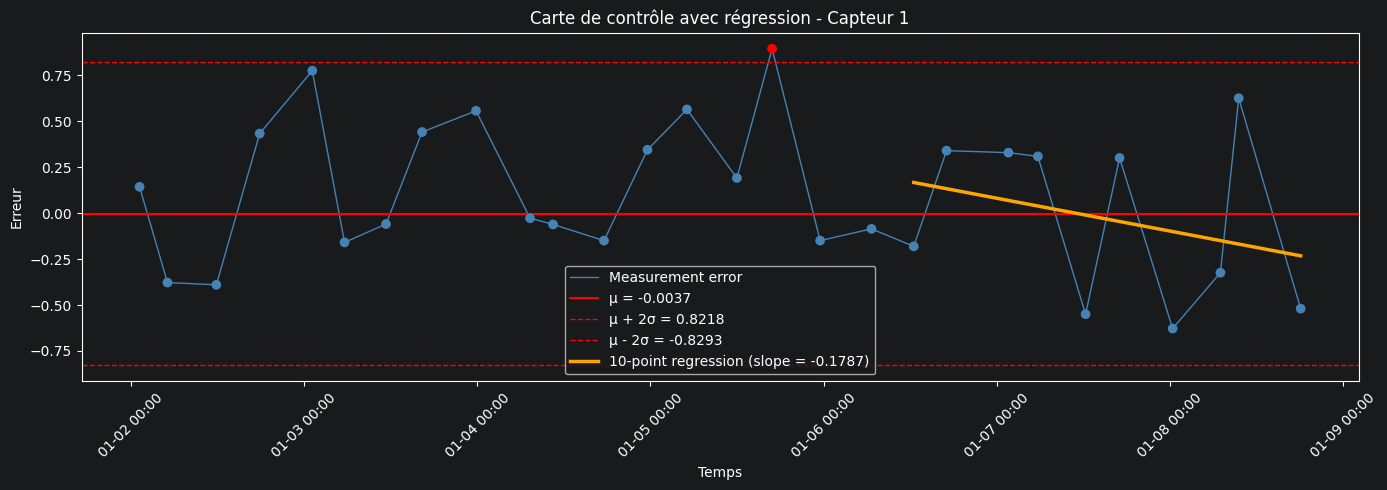

In [58]:
def PlotRegressionChart(timestamps, errors, mu, sigma, sensor_id):
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ["red" if (e < mu - 2*sigma or e > mu + 2*sigma) else "steelblue" for e in errors]
    ax.plot(timestamps, errors, color="steelblue", linewidth=1, label="Measurement error")
    ax.scatter(timestamps, errors, color=colors, zorder=5)
    ax.axhline(mu, color="red", linestyle="-", linewidth=1.5, label=f"µ = {mu:.4f}")
    ax.axhline(mu + 2*sigma, color="red", linestyle="--", linewidth=1, label=f"µ + 2σ = {mu+2*sigma:.4f}")
    ax.axhline(mu - 2*sigma, color="red", linestyle="--", linewidth=1, label=f"µ - 2σ = {mu-2*sigma:.4f}")
    last_10_times = np.array(timestamps[-10:])
    last_10_errors = np.array(errors[-10:], dtype=float)
    x_num = mdates.date2num(last_10_times)
    slope, intercept = np.polyfit(x_num, last_10_errors, 1)
    regression_line = slope * x_num + intercept
    ax.plot(last_10_times, regression_line, color="orange", linewidth=2.5,
            label=f"10-point regression (slope = {slope:.4f})")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    plt.xticks(rotation=45)
    ax.set_title(f"Carte de contrôle avec régression - Capteur {sensor_id}")
    ax.set_xlabel("Temps")
    ax.set_ylabel("Erreur")
    ax.legend()
    plt.tight_layout()
    plt.show()


PlotRegressionChart(timestamps, errors, mu, sigma, SENSOR_ID)

In [61]:
import psycopg

# Connexion
conn = psycopg.connect(
    host="localhost",
    dbname="postgres",
    user="postgres",
    password="admin"
)

print("Connecté à localhost")

# Créer la table sensor_event
with conn.cursor() as cur:
    cur.execute("DROP TABLE IF EXISTS sensor_event CASCADE;")

    cur.execute("""
                CREATE TABLE sensor_event
                (
                    event_id   SERIAL PRIMARY KEY,
                    sensor_id  INT  NOT NULL,
                    event_type TEXT NOT NULL,
                    CHECK (event_type IN ('commissioning', 'recalibration', 'disposal')),
                    event_date DATE NOT NULL
                );
                """)

    conn.commit()

print("Table sensor_event cree")

# Insérer les données de test
with conn.cursor() as cur:
    cur.execute("""
                INSERT INTO sensor_event (sensor_id, event_date, event_type)
                VALUES (1, '2022-01-01', 'commissioning'),
                       (2, '2022-03-01', 'commissioning'),
                       (3, '2022-06-15', 'commissioning'),
                       (4, '2022-07-01', 'commissioning'),
                       (1, '2022-06-10', 'recalibration'),
                       (1, '2023-01-05', 'recalibration'),
                       (2, '2022-09-01', 'recalibration'),
                       (3, '2023-01-20', 'recalibration'),
                       (2, '2023-05-01', 'disposal'),
                       (4, '2022-09-15', 'disposal');
                """)

    conn.commit()

print("Données insérées")

# Vérifier
with conn.cursor() as cur:
    cur.execute("SELECT COUNT(*) FROM sensor_event;")
    count = cur.fetchone()[0]

print(f" {count} événements dans la table")

Connecté à localhost
Table sensor_event cree
Données insérées
 10 événements dans la table


In [62]:
# SECTION 2 : Les 3 requêtes SQL avec VUES TEMPORAIRES (WITH)

# REQUÊTE 1: Nombre moyen de réétalonnages par an
print("\n REQUÊTE 1 ")

sql1 = """
       WITH recalibration_view AS (
           SELECT sensor_id, event_date
           FROM sensor_event
           WHERE event_type = 'recalibration'
       )
       SELECT AVG(nb_par_an) AS moyenne_reetalonnages_par_an
       FROM (SELECT COUNT(*) AS nb_par_an
             FROM recalibration_view
             GROUP BY sensor_id, DATE_PART('year', event_date)) AS temp;
       """

with conn.cursor() as cur:
    cur.execute(sql1)
    result = cur.fetchone()
    print(f"Moyenne: {result[0]}")


 REQUÊTE 1 
Moyenne: 1.00000000000000000000


In [63]:
# REQUÊTE 2: Taux de survie à 1 an
print("\n REQUÊTE 2 ")

sql2 = """
       WITH commissioning_view AS (
           SELECT sensor_id, MIN(event_date) AS commissioning_date
           FROM sensor_event
           WHERE event_type = 'commissioning'
           GROUP BY sensor_id
       ),
       disposal_view AS (
           SELECT sensor_id, event_date AS disposal_date
           FROM sensor_event
           WHERE event_type = 'disposal'
       )
       SELECT COUNT(*) * 1.0 /
              (SELECT COUNT(*) FROM commissioning_view) AS taux_survie
       FROM commissioning_view c
       LEFT JOIN disposal_view d ON c.sensor_id = d.sensor_id
       WHERE d.disposal_date IS NULL
          OR d.disposal_date - c.commissioning_date > 365;
       """

with conn.cursor() as cur:
    cur.execute(sql2)
    result = cur.fetchone()
    print(f"Taux de survie: {result[0] * 100:.1f}%")


 REQUÊTE 2 
Taux de survie: 75.0%


In [64]:
# REQUÊTE 3: Proportion ni rebut ni réétalonné (1 mois)
print("\n REQUÊTE 3 ")

sql3 = """
       WITH commissioning_view AS (
           SELECT sensor_id, MIN(event_date) AS commissioning_date
           FROM sensor_event
           WHERE event_type = 'commissioning'
           GROUP BY sensor_id
       ),
       disposal_view AS (
           SELECT sensor_id, event_date AS disposal_date
           FROM sensor_event
           WHERE event_type = 'disposal'
       ),
       recalibration_view AS (
           SELECT sensor_id, event_date AS recalibration_date
           FROM sensor_event
           WHERE event_type = 'recalibration'
       )
       SELECT COUNT(*) * 1.0 /
              (SELECT COUNT(*) FROM commissioning_view) AS proportion
       FROM commissioning_view c
       LEFT JOIN disposal_view d ON c.sensor_id = d.sensor_id
       WHERE (d.disposal_date IS NULL OR d.disposal_date - c.commissioning_date > 30)
         AND NOT EXISTS (SELECT 1
                         FROM recalibration_view r
                         WHERE r.sensor_id = c.sensor_id
                           AND r.recalibration_date - c.commissioning_date <= 30);
       """

with conn.cursor() as cur:
    cur.execute(sql3)
    result = cur.fetchone()
    print(f"Proportion: {result[0] * 100:.1f}%")

conn.close()
print("\n Terminé !")


 REQUÊTE 3 
Proportion: 100.0%

 Terminé !


![Diagramme de classes](diagramme.jpg)